# Intro to Aperiodic Derivatives Metrics

This notebook introduces a simple **derivatives regime dashboard** using Aperiodic's
`funding`, `open_interest`, and `basis` metrics for **Binance BTC perpetuals** over
**September 1, 2025 → February 28, 2026** at **5-minute** frequency.

## Why derivatives metrics matter

Derivatives data helps answer a different question than trade flow: **how crowded is positioning, and how expensive is leverage?**

- **Funding** tracks the periodic transfer that keeps perpetuals aligned with spot.
- **Open interest** helps show whether leverage is building or being unwound.
- **Basis** measures the futures/perpetual premium or discount relative to a reference price.

Together, these metrics are useful for spotting crowded bullish or bearish regimes, squeezes, and leverage resets.

**Background reading**
- Aperiodic derivatives market data: https://aperiodic.io/metrics/derivatives_market_data
- Binance Academy, funding rates: https://www.binance.com/en/academy/articles/what-are-funding-rates-in-crypto-markets
- CME Group, futures basis overview: https://www.cmegroup.com/education/courses/introduction-to-basis.html

In [1]:
from __future__ import annotations

import os
from datetime import date
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_derivative_metrics, get_ohlcv
from dotenv import load_dotenv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BASE_URL = "https://aperiodic.io/api/v1"
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 9, 1)
END_DATE = date(2026, 2, 28)
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

WORKDIR = Path.cwd().resolve()
ENV_PATH = WORKDIR / ".env"
if not ENV_PATH.exists() and (WORKDIR.parent / ".env").exists():
    ENV_PATH = WORKDIR.parent / ".env"
load_dotenv(ENV_PATH)
API_KEY = os.environ["APERIODIC_API_KEY"]


def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)

def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)



def to_bps(series: pd.Series) -> pd.Series:
    return series * 10_000

## Fetch price, funding, open interest, and basis

In [2]:
price = clip_window(
    get_ohlcv(
        api_key=API_KEY,
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        base_url=BASE_URL,
        output="pandas",
        show_progress=False,
    )
)[["time", "close"]]

funding = clip_window(
    get_derivative_metrics(
        api_key=API_KEY,
        metric="funding",
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        base_url=BASE_URL,
        output="pandas",
        show_progress=False,
    )
)

oi = clip_window(
    get_derivative_metrics(
        api_key=API_KEY,
        metric="open_interest",
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        base_url=BASE_URL,
        output="pandas",
        show_progress=False,
    )
)

basis = clip_window(
    get_derivative_metrics(
        api_key=API_KEY,
        metric="basis",
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        base_url=BASE_URL,
        output="pandas",
        show_progress=False,
    )
)

In [3]:
derivs = (
    price.merge(funding, on="time", how="inner")
    .merge(oi, on="time", how="inner")
    .merge(basis, on="time", how="inner")
)

derivs["price_return_bps_1h"] = derivs["close"].pct_change(12) * 10_000

derivs["funding_rate_bps"] = derivs["funding_rate"] * 10_000
for col in ["funding_rate_bps", "basis_bps", "open_interest"]:
    derivs[f"{col}_z_1d"] = (derivs[col] - derivs[col].rolling(288).mean()) / derivs[col].rolling(288).std()

derivs["oi_change_1h_pct"] = derivs["open_interest"].pct_change(12) * 100

derivs["next_1h_return_bps"] = derivs["close"].pct_change(12).shift(-12) * 10_000

derivs["stress_regime"] = (
    (derivs["funding_rate_bps_z_1d"] > 1.5)
    & (derivs["basis_bps_z_1d"] > 1.5)
    & (derivs["open_interest_z_1d"] > 1.0)
)

derivs["crowding_score"] = derivs[["funding_rate_bps_z_1d", "basis_bps_z_1d", "open_interest_z_1d"]].mean(axis=1)

summary = pd.Series(
    {
        "Rows": len(derivs),
        "Start": derivs["time"].min(),
        "End": derivs["time"].max(),
        "Mean funding (bps)": derivs["funding_rate_bps"].mean(),
        "Mean basis (bps)": derivs["basis_bps"].mean(),
        "Median open interest": derivs["open_interest"].median(),
        "Stress regime share": derivs["stress_regime"].mean(),
    }
)
summary

Rows                                  52128
Start                   2025-09-01 00:00:00
End                     2026-02-28 23:55:00
Mean funding (bps)                   0.3911
Mean basis (bps)                    -4.2997
Median open interest            89,319.8745
Stress regime share                  0.0053
dtype: object

## Charts 1-2 — BTC price and funding rate

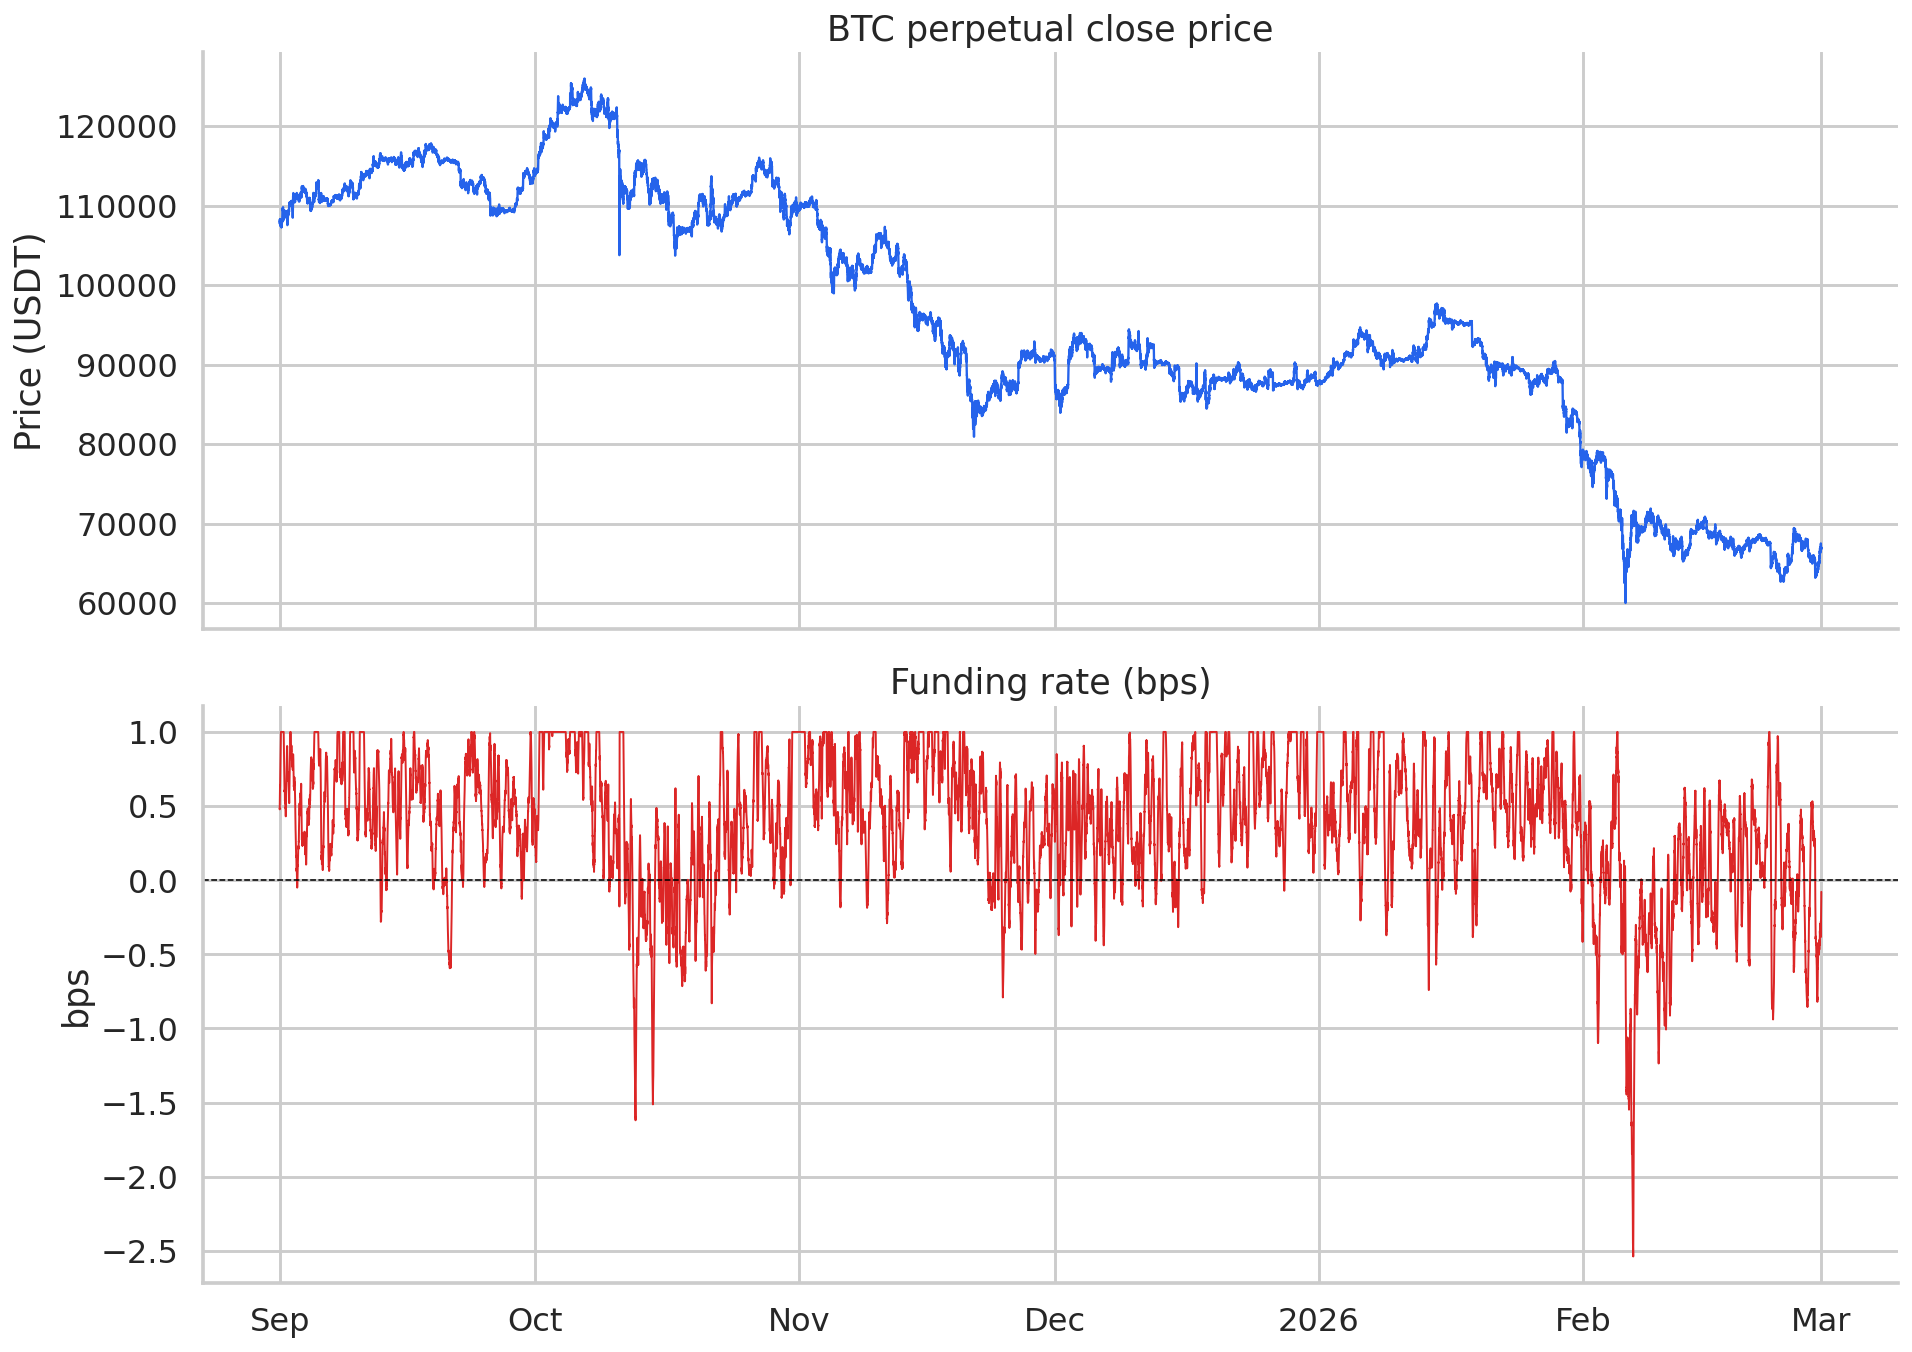

In [4]:
fig, (ax_price, ax_funding) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax_price.plot(derivs["time"], derivs["close"], color="#2563eb", linewidth=1.2)
ax_price.set_title("BTC perpetual close price")
ax_price.set_ylabel("Price (USDT)")
format_time_axis(ax_price)

ax_funding.plot(derivs["time"], derivs["funding_rate_bps"], color="#dc2626", linewidth=1)
ax_funding.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax_funding.set_title("Funding rate (bps)")
ax_funding.set_ylabel("bps")
format_time_axis(ax_funding)
plt.tight_layout()

## Chart 3 — Funding distribution

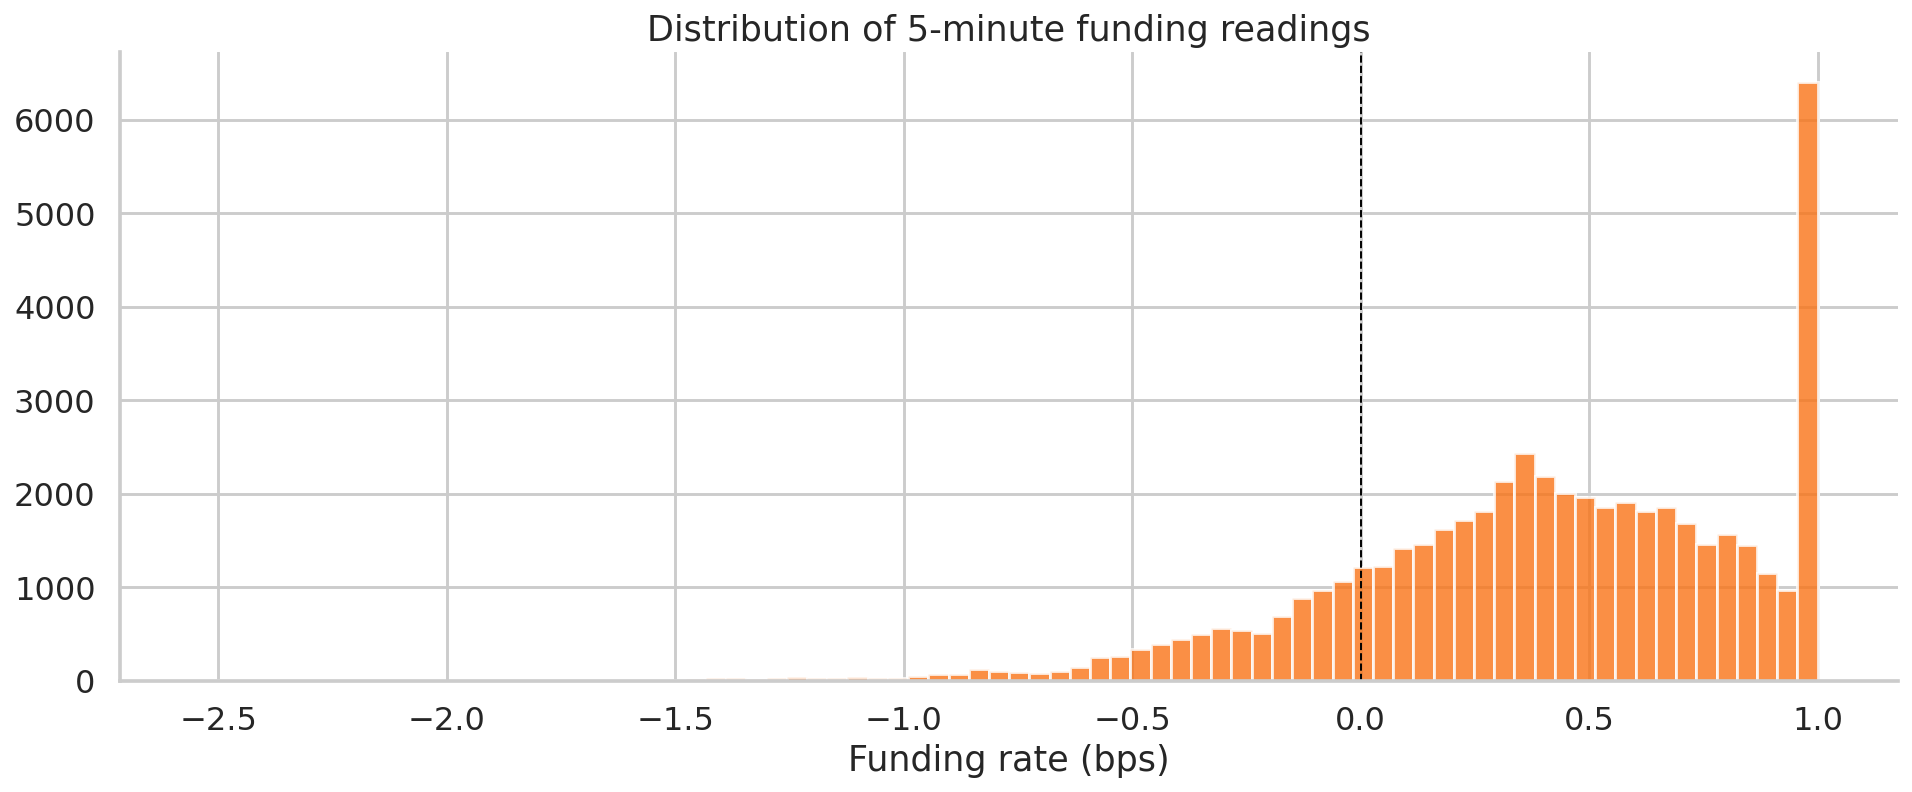

In [5]:
fig, ax = plt.subplots()
ax.hist(derivs["funding_rate_bps"].dropna(), bins=80, color="#f97316", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Distribution of 5-minute funding readings")
ax.set_xlabel("Funding rate (bps)")
plt.tight_layout()

## Chart 4 — Open interest

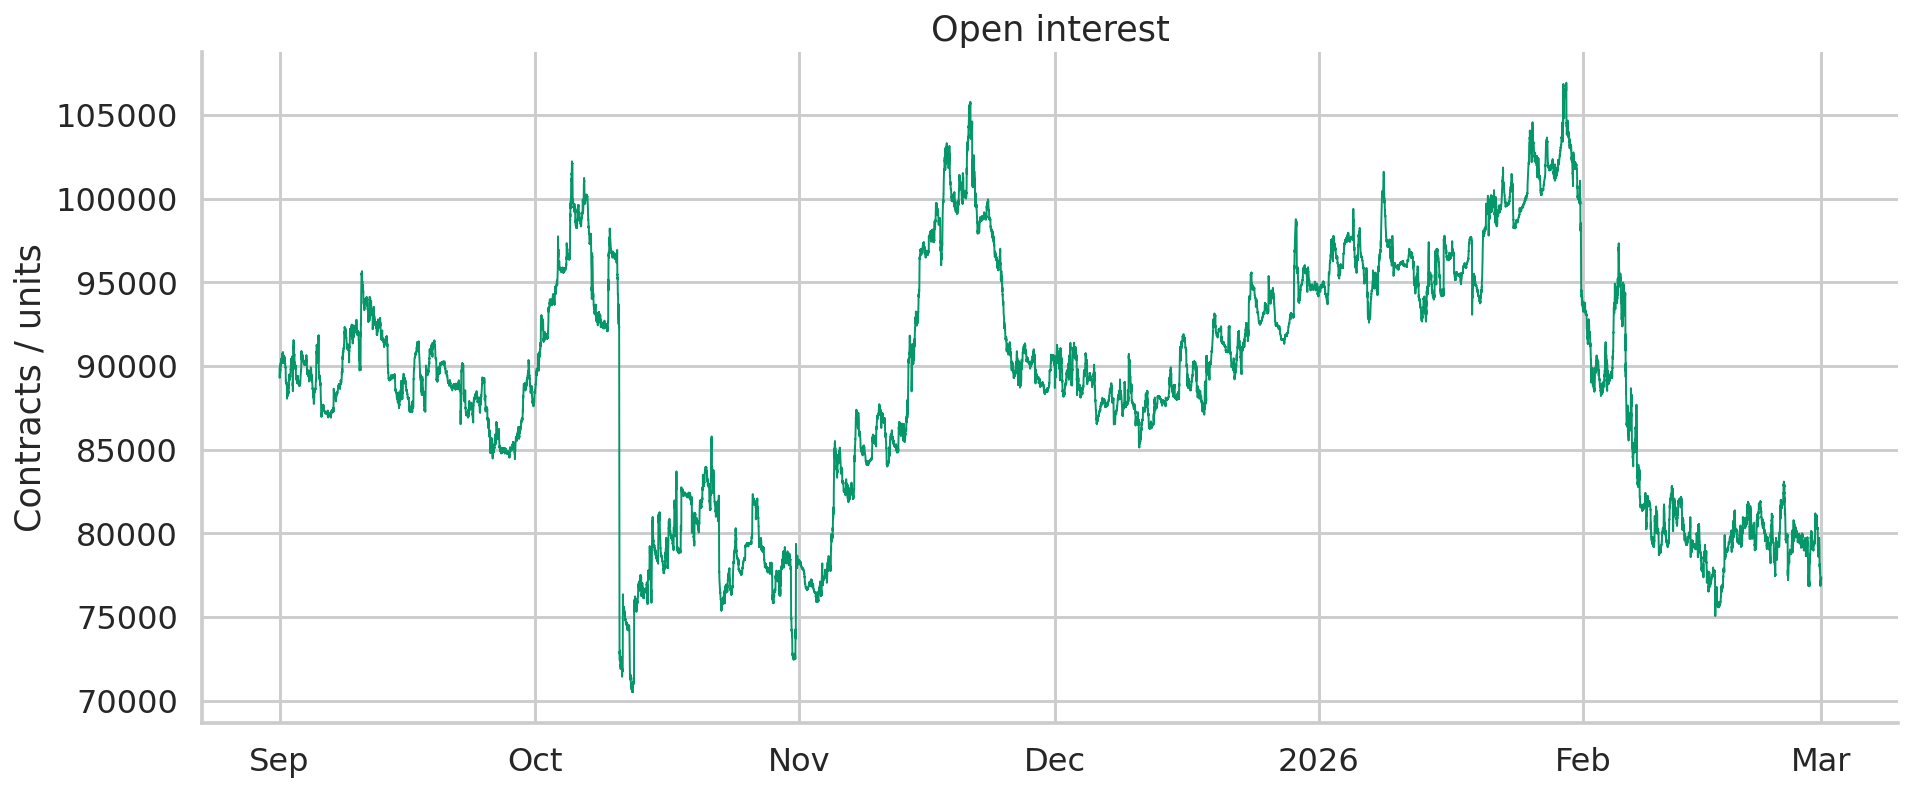

In [6]:
fig, ax = plt.subplots()
ax.plot(derivs["time"], derivs["open_interest"], color="#059669", linewidth=1)
ax.set_title("Open interest")
ax.set_ylabel("Contracts / units")
format_time_axis(ax)
plt.tight_layout()

## Chart 5 — Price vs open interest

A rising market with rising open interest often suggests leverage is building alongside the move.

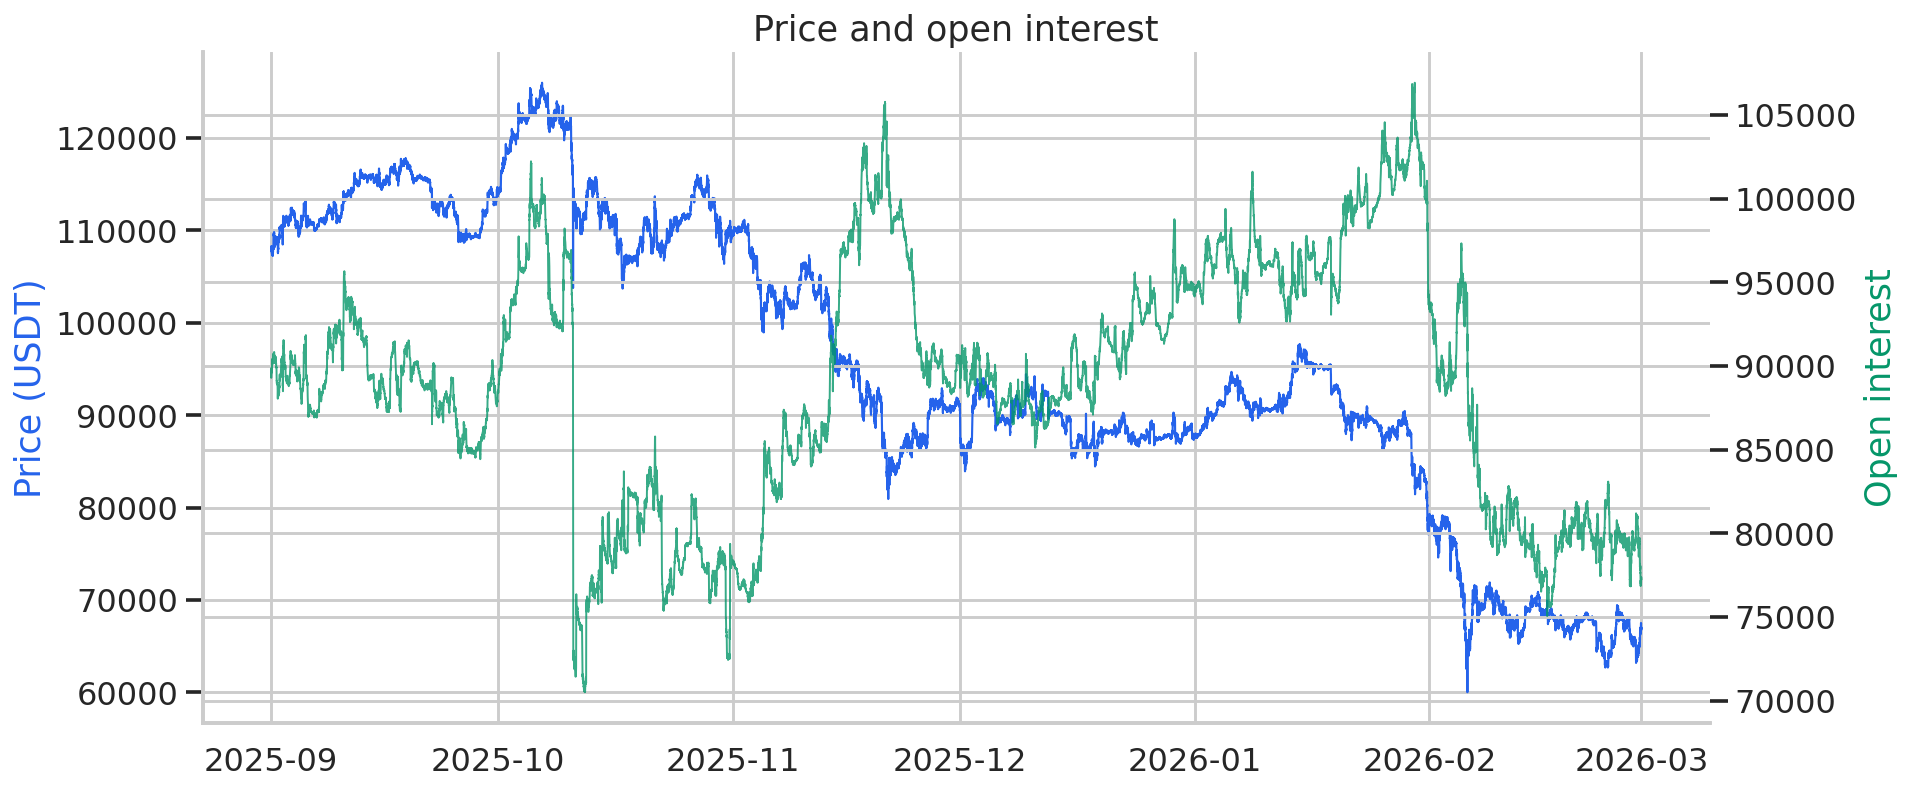

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(derivs["time"], derivs["close"], color="#2563eb", linewidth=1.1, label="Close")
ax1.set_ylabel("Price (USDT)", color="#2563eb")
ax2 = ax1.twinx()
ax2.plot(derivs["time"], derivs["open_interest"], color="#059669", linewidth=1, alpha=0.8, label="Open interest")
ax2.set_ylabel("Open interest", color="#059669")
ax1.set_title("Price and open interest")
format_time_axis(ax)
plt.tight_layout()

## Chart 6 — Basis in basis points

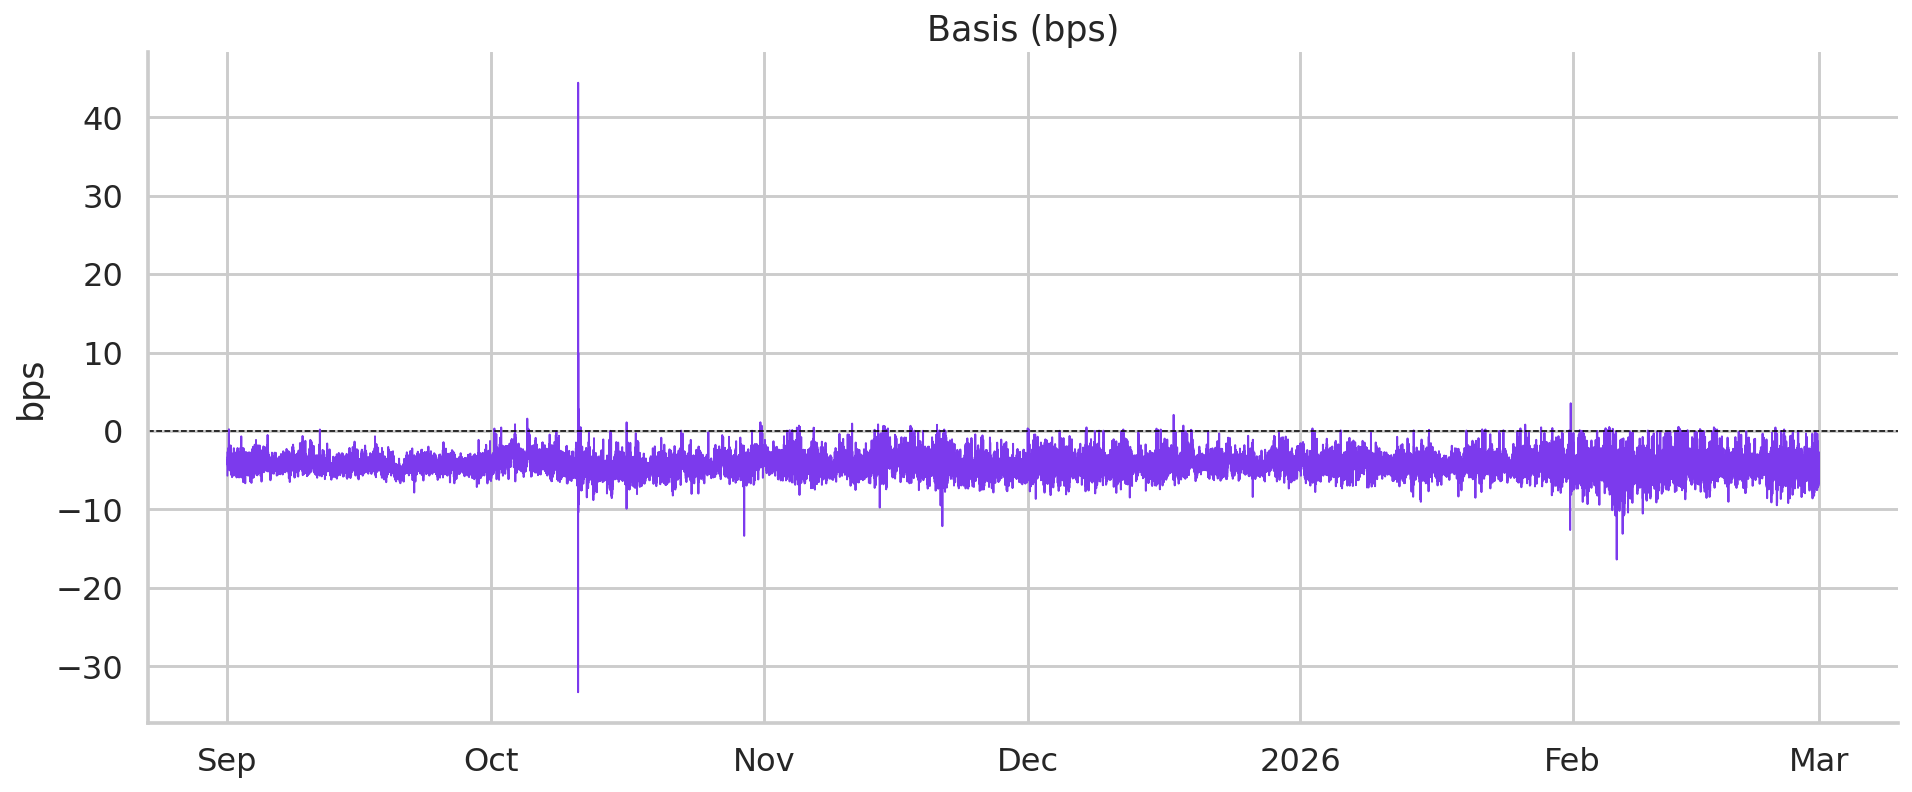

In [8]:
fig, ax = plt.subplots()
ax.plot(derivs["time"], derivs["basis_bps"], color="#7c3aed", linewidth=1)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Basis (bps)")
ax.set_ylabel("bps")
format_time_axis(ax)
plt.tight_layout()

## Chart 7 — Crowding score and highlighted stress regimes

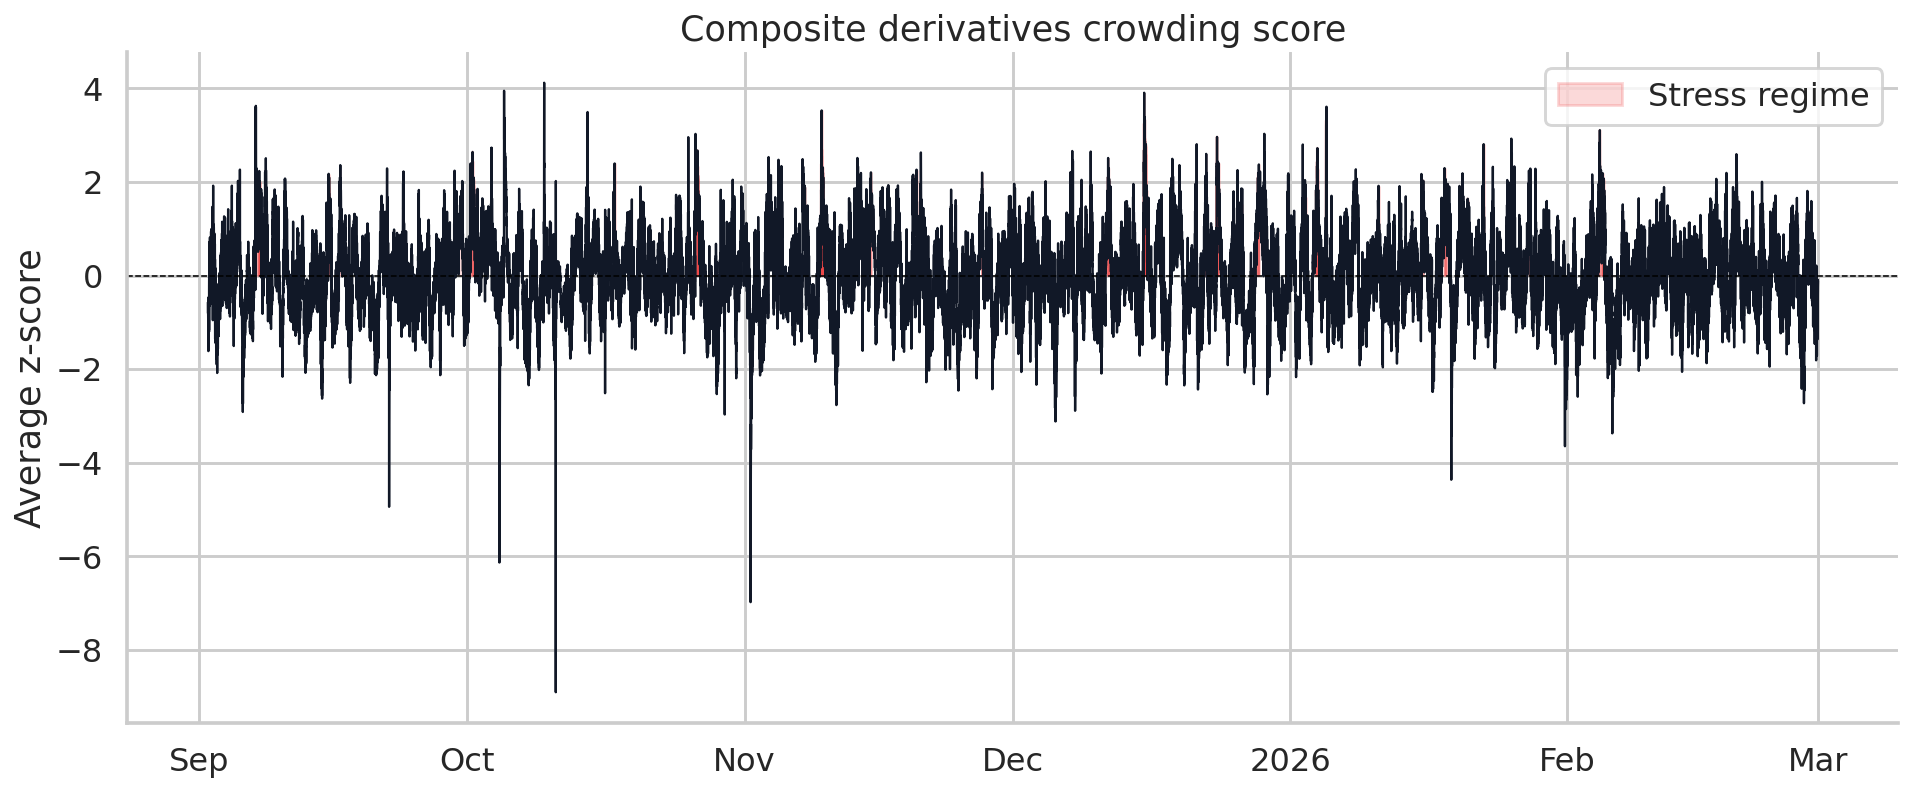

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(derivs["time"], derivs["crowding_score"], color="#111827", linewidth=1.2)
ax.fill_between(
    derivs["time"],
    derivs["crowding_score"],
    where=derivs["stress_regime"],
    color="#ef4444",
    alpha=0.2,
    label="Stress regime",
)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Composite derivatives crowding score")
ax.set_ylabel("Average z-score")
ax.legend(frameon=True)
format_time_axis(ax)
plt.tight_layout()

## Chart 8 — Basis vs next 1-hour returns

This scatter helps visualize whether richer or cheaper perp pricing tended to coincide with subsequent mean reversion or continuation.

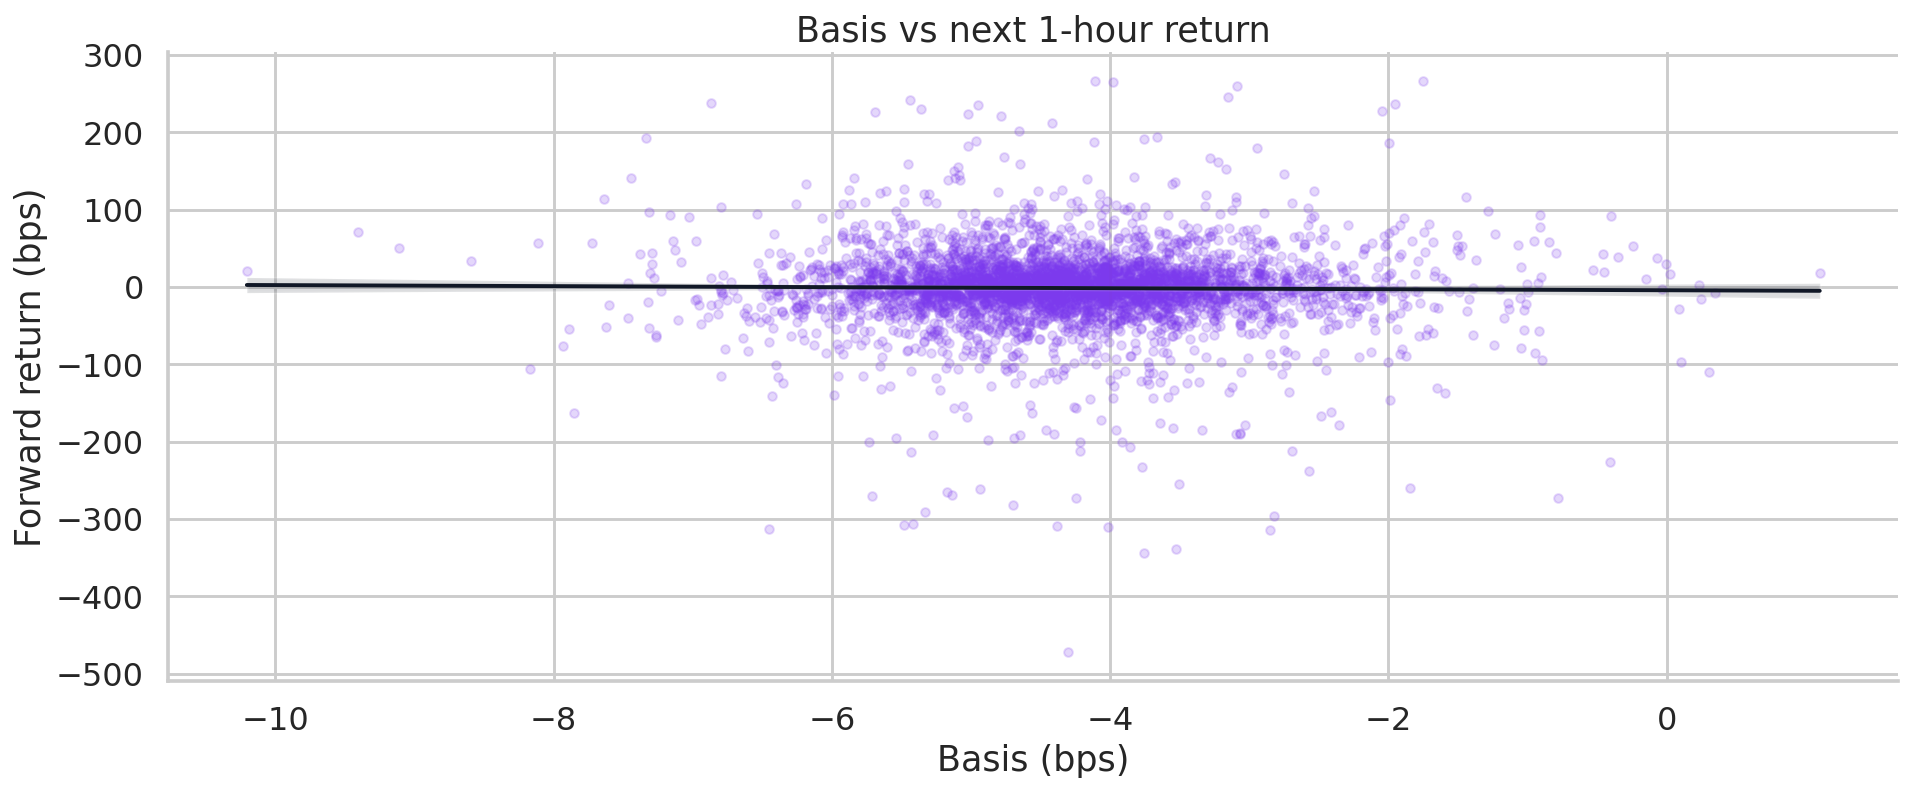

In [10]:
scatter = derivs[["basis_bps", "next_1h_return_bps"]].dropna()
fig, ax = plt.subplots()
sns.regplot(
    data=scatter.sample(min(len(scatter), 4000), random_state=7),
    x="basis_bps",
    y="next_1h_return_bps",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#7c3aed"},
    line_kws={"color": "#111827", "linewidth": 2},
    ax=ax,
)
ax.set_title("Basis vs next 1-hour return")
ax.set_xlabel("Basis (bps)")
ax.set_ylabel("Forward return (bps)")
plt.tight_layout()

## Chart 9 — Funding by weekday and hour

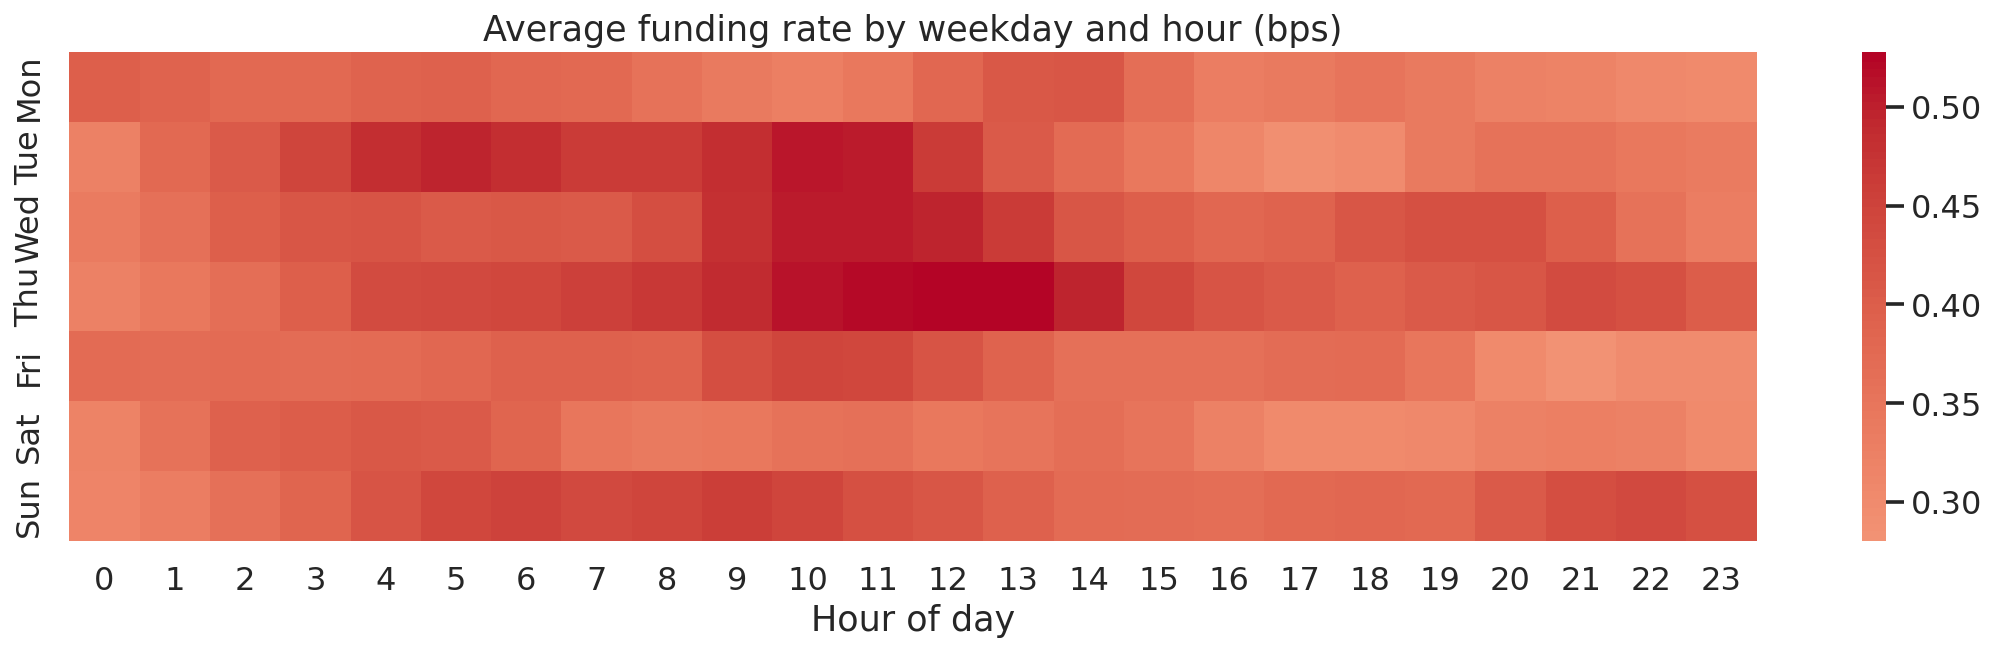

In [11]:
seasonality = derivs.assign(
    weekday=derivs["time"].dt.day_name().str[:3],
    hour=derivs["time"].dt.hour,
).pivot_table(index="weekday", columns="hour", values="funding_rate_bps", aggfunc="mean")
seasonality = seasonality.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(seasonality, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Average funding rate by weekday and hour (bps)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()

## Most crowded snapshots

In [12]:
derivs.nlargest(10, "crowding_score")[[
    "time",
    "close",
    "funding_rate_bps",
    "basis_bps",
    "open_interest",
    "oi_change_1h_pct",
    "crowding_score",
    "next_1h_return_bps",
]].reset_index(drop=True)

,time,close,funding_rate_bps,basis_bps,open_interest,oi_change_1h_pct,crowding_score,next_1h_return_bps
0,2025-10-09 14:05:00,"121,977.9000",0.6023,-1.8920,"94,857.2460",2.6913,4.1221,-44.6884
1,2025-10-05 02:30:00,"124,116.2000",1.0000,1.5715,"98,152.6050",1.7703,3.9508,-3.0214
2,2025-12-15 16:05:00,"87,171.5000",0.3043,0.3017,"90,384.1170",1.6098,3.9084,-109.4050
3,2025-09-07 08:25:00,"111,199.9000",0.4541,-2.5854,"88,277.6850",0.9277,3.6281,-6.9514
4,2026-01-05 01:15:00,"92,800.0000",1.0000,-1.2582,"99,331.3280",0.8366,3.6095,15.2909
5,2025-09-07 08:35:00,"111,180.3000",0.5085,-2.6710,"88,550.5730",1.1870,3.6068,-20.8760
6,2025-11-09 14:40:00,"103,322.9000",0.8888,-0.3731,"85,635.1630",0.6298,3.5301,45.4981
7,2025-10-14 10:35:00,"110,540.8000",-0.0083,-1.1025,"79,222.3030",2.3179,3.4964,70.3451
8,2025-12-15 16:50:00,"86,383.9000",0.3631,-1.1193,"90,748.2880",0.9132,3.3875,-75.9169
9,2025-10-05 02:45:00,"123,775.6000",1.0000,0.0959,"98,738.3130",2.3132,3.3806,14.1223


## Takeaways

- Funding, basis, and open interest are complementary measures of **leverage, crowding, and carry**.
- Persistent positive funding plus rich basis often signals an increasingly expensive long trade.
- Rising open interest during a price move can indicate fresh positioning rather than mere price drift.
- The most useful regime read usually comes from **the combination** of these metrics, not any one series in isolation.

## Further reading
- Aperiodic derivatives market data: https://aperiodic.io/metrics/derivatives_market_data
- Funding rates: https://www.binance.com/en/academy/articles/what-are-funding-rates-in-crypto-markets
- Basis overview: https://www.cmegroup.com/education/courses/introduction-to-basis.html